## Exercise 3: Optomotor response

The [optomotor response](https://en.wikipedia.org/wiki/Optomotor_response) is an innate behavior commonly observed in insects and fish. It facilitates their movement in alignment with the direction of motion, allowing them to compensate for unforeseen disturbances such as gusts of air.

In this exercise, we will simulate the process by which a fly determines the direction of moving gratings and adjusts its turning in response. Similar experiments have been done in previous studies, such as by [Strauss, Schuster, and Götz (1997)](https://doi.org/10.1242/jeb.200.9.1281).

First, let's create an arena class for the grating stimulus. We add black cylinders around the fly to simulate the visual experience of gratings, as shown in the schematic below:

<img src="assets/gratings.png" width="256">

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mediapy
from tqdm import trange

from flygym.compose.world import FlatGroundWorld
from flygym.simulation import Simulation
from utils import create_fly, create_simulation, show_video


class Gratings(FlatGroundWorld):
    """Circular arena with rotating cylinders to simulate a grating pattern."""

    def __init__(self, n=8, d=800, h=4000, ang_speed=np.pi, interval=0.5, **kwargs):
        """Create a circular arena with *n* cylinders.

        Parameters
        ----------
        n : int
            Number of cylinders to place around the fly.
        d : float
            Distance from the arena center to each cylinder center.
        h : float
            Height of the cylinders.
        ang_speed : float
            Angular speed of the grating rotation (rad/s).
        interval : float
            Time interval between direction reversals (seconds).
        """
        super().__init__(**kwargs)
        for geom in self.ground_contact_geoms:
            geom.rgba = (0, 0, 0, 0)
        self.h = h
        self.ang_speed = ang_speed
        self.interval = interval
        self.cylinders = []
        ################################################################
        # TODO: Calculate the radius and the initial positions of the
        # cylinders.
        # Hint: The cylinder diameters should equal the side length of
        # a 2n-gon inscribed in a circle of radius d, so that black
        # and white stripes occupy equal areas on the visual field.
        r = d * np.sin(np.pi / (2 * n))
        init_angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
        init_pos = np.stack([
            d * np.cos(init_angles),
            d * np.sin(init_angles),
        ], axis=1)     
        ################################################################
        self.init_pos = init_pos

        for k, pos in enumerate(init_pos):
            cylinder = self.mjcf_root.worldbody.add(
                "body",
                name=f"cylinder_{k}",
                mocap=True,
                ########################################################
                # TODO: Set the position of the cylinder
                pos=(pos[0],pos[1], 0),
                ########################################################
            )
            cylinder.add(
                "geom",
                type="cylinder",
                size=(r, self.h / 2),
                rgba=(0, 0, 0, 1),
            )
            self.cylinders.append(cylinder)

    def step(self, sim: Simulation):
        """Advance the grating rotation by one physics step."""
        mocap_ids = np.array(
            [sim.mj_model.body(c.name).mocapid.item() for c in self.cylinders]
        )
        t = abs((sim.time + self.interval) % (self.interval * 2) - self.interval)
        angle = self.ang_speed * t
        ################################################################
        # TODO: Update the positions of the cylinders to achieve the 
        # rotation effect.
        
        rot = np.array([[np.cos(angle), -np.sin(angle)],
                        [np.sin(angle),  np.cos(angle)]])          

        pos = (rot @ self.init_pos.T).T            

        sim.mj_data.mocap_pos[mocap_ids, 0] = pos[:, 0]  
        sim.mj_data.mocap_pos[mocap_ids, 1] = pos[:, 1]   
        ################################################################

In [2]:
world = Gratings()
fly = create_fly(enable_vision=True)
sim = create_simulation(world=world, fly=fly, camera_kwargs={"pos": (0, 0, 20)})

frames = []
for i in trange(10000):
    world.step(sim)
    sim.step()
    if sim.render_as_needed():
        ommatidia_readouts = sim.get_ommatidia_readouts(fly.name)
        im = np.concatenate(
            [
                fly.retina.hex_pxls_to_human_readable(eye.max(-1), color_8bit=True)
                for eye in ommatidia_readouts
            ],
            axis=1,
        )
        frames.append(im)

show_video(sim)
mediapy.show_video(frames, fps=sim.renderer.output_fps, title="Ommatidia readouts")

100%|██████████| 10000/10000 [00:26<00:00, 373.66it/s]


birdeyecam This browser does not support the video tag.


Ommatidia readouts This browser does not support the video tag.


To simplify array operations on visual inputs, we define a helper function to extract and reshape the central rectangular region from the hexagonal ommatidium layout.

Shape: (2, 16, 31)


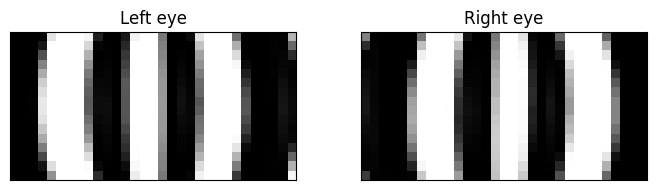

In [3]:
def crop_hex_to_rect(ommatidia_readouts, ommatidia_id_map):
    """Extract a rectangular patch from the hexagonal ommatidium layout.

    Parameters
    ----------
    ommatidia_readouts : np.ndarray
        Ommatidia readings, shape ``(2, n_ommatidia, n_channels)``.
    ommatidia_id_map : np.ndarray
        2D map of ommatidium IDs from ``retina.ommatidia_id_map``.

    Returns
    -------
    np.ndarray
        Cropped rectangular image, shape ``(2, n_rows, n_cols)``.
    """
    rows = [np.unique(row) for row in ommatidia_id_map]
    max_width = max(len(row) for row in rows)
    rows = np.array([row for row in rows if len(row) == max_width])[:, 1:] - 1
    cols = [np.unique(col) for col in rows.T]
    min_height = min(len(col) for col in cols)
    cols = [col[:min_height] for col in cols]
    rows = np.array(cols).T
    return ommatidia_readouts[..., rows, :].max(-1)


imgs = crop_hex_to_rect(ommatidia_readouts, fly.retina.ommatidia_id_map)

fig, axs = plt.subplots(1, 2, figsize=(8, 2), tight_layout=True)
axs[0].imshow(imgs[0], cmap="gray", vmin=0, vmax=1)
axs[0].set_title("Left eye")
axs[1].imshow(imgs[1], cmap="gray", vmin=0, vmax=1)
axs[1].set_title("Right eye")
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

print("Shape:", imgs.shape)

<img src="assets/hrc.png" width="150">

We will use the **Hassenstein–Reichardt Correlator (HRC)** model to detect motion from two adjacent photoreceptors. In the schematic above, $x_i$ and $x_{i+1}$ refer to the positions of two adjacent photoreceptors.

**TODO:** Express the output of the HRC model using the previous light intensities $I(x_i,t-\tau)$, $I(x_{i+1},t-\tau)$ and the current light intensities $I(x_i,t)$, $I(x_{i+1},t)$.

*Your answer here*

$I(x_{i},t-\tau)*I(x_{i+1},t)-I(x_{i},t)*I(x_{i+1},t-\tau)$

Next, implement the HRC model as a function:

In [4]:
from numpy.lib.stride_tricks import sliding_window_view


def get_horizontal_hrc_responses(I_prev, I_curr):
    """Calculate the horizontal optic flow using the HRC model.

    Parameters
    ----------
    I_prev : np.ndarray
        Previous light intensities, shape ``(n_rows, n_cols)``.
    I_curr : np.ndarray
        Current light intensities, shape ``(n_rows, n_cols)``.

    Returns
    -------
    np.ndarray
        Horizontal optic flow, shape ``(n_rows, n_cols - 1)``.
    """
    ############################################################
    # TODO: Calculate the horizontal optic flow using the HRC
    # model.
    # Hint: For a 2D array I of shape (n_rows, n_cols),
    # sliding_window_view(I, 2, axis=-1) returns a view of
    # shape (n_rows, n_cols - 1, 2) with a sliding window of
    # size 2 along the horizontal axis (last axis).
    windows_prev=sliding_window_view(I_prev,2,axis=-1)
    windows_curr=sliding_window_view(I_curr,2,axis=-1)
    return windows_prev[:,:,0]*windows_curr[:,:,1]-windows_curr[:,:,0]*windows_prev[:,:,1]
    ############################################################

Let's verify the function with an example.

Text(0, 0.5, 'HRC response')

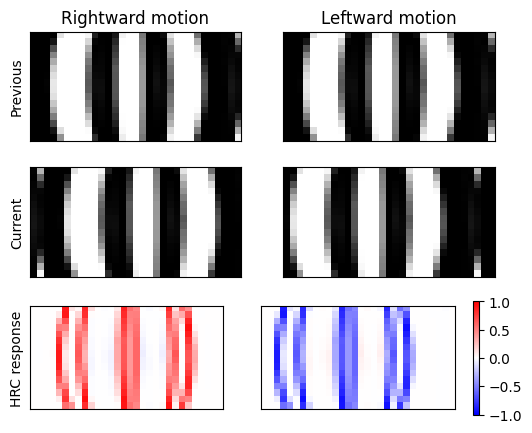

In [5]:
fig, axs = plt.subplots(3, 2, figsize=(6, 5))

# Rightward motion
I_prev = imgs[0]
I_curr = np.roll(I_prev, 2, axis=1)
axs[0, 0].imshow(I_prev, cmap="gray", vmin=0, vmax=1)
axs[1, 0].imshow(I_curr, cmap="gray", vmin=0, vmax=1)
axs[2, 0].imshow(
    get_horizontal_hrc_responses(I_prev, I_curr), cmap="bwr", vmin=-1, vmax=1
)

# Leftward motion
I_prev = imgs[0]
I_curr = np.roll(I_prev, -2, axis=1)
axs[0, 1].imshow(I_prev, cmap="gray", vmin=0, vmax=1)
axs[1, 1].imshow(I_curr, cmap="gray", vmin=0, vmax=1)
im = axs[2, 1].imshow(
    get_horizontal_hrc_responses(I_prev, I_curr), cmap="bwr", vmin=-1, vmax=1
)

for ax in axs.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axs[2, :], orientation="vertical", fraction=0.046, pad=0.04)
axs[0, 0].set_title("Rightward motion")
axs[0, 1].set_title("Leftward motion")
axs[0, 0].set_ylabel("Previous")
axs[1, 0].set_ylabel("Current")
axs[2, 0].set_ylabel("HRC response")

Finally, we can simulate how the fly detects the motion direction and turns accordingly:

In [7]:
from flygym.examples.locomotion import TurningController
from flygym.compose import ActuatorType

world = Gratings()
fly = create_fly(enable_vision=True)
sim = create_simulation(world=world, fly=fly, camera_kwargs={"pos": (0, 0, 20)})
controller = TurningController(sim.timestep)

sim.step()
n_delays = 2
prev_ommatidia_readouts = sim.get_ommatidia_readouts(fly.name)
I_hist = [
    crop_hex_to_rect(prev_ommatidia_readouts, fly.retina.ommatidia_id_map)
] * n_delays

action = np.array([0.0, 0.0])
mean_hrc_response_smooth = 0.0

for i in trange(20000):
    world.step(sim)
    ommatidia_readouts = sim.get_ommatidia_readouts(fly.name)

    if prev_ommatidia_readouts is not ommatidia_readouts:
        I_prev = I_hist.pop(0)
        I_curr = crop_hex_to_rect(ommatidia_readouts, fly.retina.ommatidia_id_map)
        I_hist.append(I_curr)
        mean_hrc_response = np.mean(
            [get_horizontal_hrc_responses(I_prev[j], I_curr[j]) for j in range(2)]
        )
        mean_hrc_response_smooth = (
            0.9 * mean_hrc_response_smooth + 0.1 * mean_hrc_response
        )

        ################################################################
        # TODO: Apply turning descending signals to make the fly turn
        # towards the grating's movement direction.
        action = np.array([mean_hrc_response_smooth,-mean_hrc_response_smooth])
        ################################################################

        prev_ommatidia_readouts = ommatidia_readouts

    joint_angles, adhesion = controller.step(action)
    sim.set_actuator_inputs(fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(fly.name, ActuatorType.ADHESION, adhesion)
    sim.render_as_needed()
    sim.step()

show_video(sim)

100%|██████████| 20000/20000 [01:30<00:00, 221.40it/s]
